# Spatial Reasoning Probing Study

**Nora Gully — CSCI 4622 Machine Learning, Spring 2026**

Repo: [https://github.com/nogully/spatial_probing](https://github.com/nogully/spatial_probing)

---

Note: For your convenience, this notebook loads pre-computed results. No GPU or model downloads required. All expensive computation (embedding extraction, probe training) was run separately and cached.

AI disclosure: I used Claude Code to assist with coding in this project, as encouraged in the course. Research question, experimental decisions, and interpretation are my own based on this and my other NLP class.

## Research Question

> Does visual contrastive training (CLIP) produce text embeddings that encode spatial relations better than text contrastive training (SBERT)? And which specific spatial relation types benefit — or remain resistant?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from datasets import load_dataset

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

np.random.seed(42)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Results directory: {RESULTS_DIR}")
print(f"CSVs available:")
for f in sorted(RESULTS_DIR.glob("*.csv")):
    print(f"  {f.name}")
print(f"Figures available:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name}")

/Users/norair/Documents/Code/Projects/spatial_probing/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Results directory: /Users/norair/Documents/Code/Projects/spatial_probing/results
CSVs available:
  probing_results.csv
  probing_results_clip_concat_detailed.csv
  probing_results_clip_image_detailed.csv
  probing_results_clip_mm_detailed.csv
  probing_results_clip_text_detailed.csv
  probing_results_sbert_detailed.csv
  probing_results_with_gains.csv
  summary_statistics.csv
Figures available:
  05_clip_gains.png
  05_main_heatmap.png
  05_model_comparison.png


---

## 1. Dataset: Visual Spatial Reasoning (VSR)

**Liu et al. (2022)** — [Visual Spatial Reasoning](https://arxiv.org/abs/2205.00363)

Each example is an `(image, caption, relation_type, label: True/False)` tuple. The caption describes a spatial relation between two objects in the image; the label indicates whether the caption is correct. Images are COCO photographs.

64 spatial relation types across three categories:
- **Projective**: above, below, left of, right of, in front of, behind
- **Topological**: inside, on, touching, containing
- **Proximal**: near, far from, next to, beside

In [2]:
print("Loading VSR dataset (metadata only — no GPU required)...")
vsr = load_dataset("cambridgeltl/vsr_random")

print(f"\nDataset split sizes:")
for split, ds in vsr.items():
    print(f"  {split:10s}: {len(ds):,} examples")

print(f"\nRelation types: {len(set(ex['relation'] for ex in vsr['train']))} unique")
train_labels = [int(ex["label"]) for ex in vsr["train"]]
print(f"Label balance:  {sum(train_labels)/len(train_labels):.1%} True, {1 - sum(train_labels)/len(train_labels):.1%} False")

Loading VSR dataset (metadata only — no GPU required)...

Dataset split sizes:
  train     : 7,680 examples
  validation: 1,097 examples
  test      : 2,195 examples

Relation types: 64 unique
Label balance:  50.5% True, 49.5% False


---

## 2. Models

Four embedding conditions, chosen to isolate the effect of visual grounding:

| Model | Training objective | Visual signal | Dim |
|---|---|---|---|
| **SBERT** (`all-mpnet-base-v2`) | NLI + semantic similarity | None | 768 |
| **CLIP Text** (`clip-vit-base-patch32`, text encoder) | Contrastive image-text | Indirect (training only) | 512 |
| **CLIP Image** (image encoder) | Contrastive image-text | Direct | 512 |
| **CLIP Concat** (image + text, concatenated) | Contrastive image-text | Both | 1024 |

**Key architectural note**: Both SBERT and CLIP text encoder produce a single dense sentence vector (mean-pooled tokens vs. pooled `[EOS]` token respectively). This is why probing comparison is valid — both produce fixed-size vectors of the same conceptual type.

**Probing design**:
- Logistic regression probe per relation type (binary: is this relation present?)
- Stratified 5-fold cross-validation
- Metric: macro F1 (handles class imbalance)
- Regularization: C=1.0 (weak, to test the representation not the probe)
- Relations with fewer than 50 examples excluded (36 of 64 relations retained)

---

## 3. Probing Results

In [3]:
# Load pre-computed results
results = pd.read_csv(RESULTS_DIR / "probing_results.csv")
summary = pd.read_csv(RESULTS_DIR / "summary_statistics.csv")

print("=" * 60)
print("SUMMARY: Mean F1 by Model (36 relations, min 50 examples)")
print("=" * 60)
print(summary[["Model", "Mean F1", "Std F1", "Median F1", "Min F1", "Max F1"]].round(3).to_string(index=False))

SUMMARY: Mean F1 by Model (36 relations, min 50 examples)
      Model  Mean F1  Std F1  Median F1  Min F1  Max F1
      SBERT    0.710   0.188      0.661   0.497   0.989
  CLIP Text    0.589   0.139      0.498   0.493   0.981
 CLIP Image    0.493   0.006      0.495   0.469   0.498
CLIP Concat    0.514   0.077      0.496   0.484   0.902


In [4]:
# Full per-relation results table
print("Per-relation F1 scores (sorted by SBERT F1):")
display_cols = ["relation", "sbert_f1", "clip_text_f1", "clip_image_f1", "clip_concat_f1"]
print(results[display_cols].round(3).to_string(index=False))

Per-relation F1 scores (sorted by SBERT F1):
            relation  sbert_f1  clip_text_f1  clip_image_f1  clip_concat_f1
            touching     0.989         0.981          0.469           0.902
           on top of     0.951         0.951          0.488           0.724
       far away from     0.964         0.865          0.495           0.495
              behind     0.972         0.787          0.483           0.491
               under     0.875         0.780          0.486           0.543
 at the left side of     0.914         0.731          0.491           0.491
         in front of     0.921         0.733          0.482           0.484
at the right side of     0.932         0.633          0.489           0.489
               above     0.860         0.639          0.492           0.492
             left of     0.940         0.544          0.495           0.495
    facing away from     0.953         0.496          0.496           0.496
              facing     0.941         0.49

In [5]:
# How often does each model "win"?
print("Relations where each model has highest F1:")
model_cols = ["sbert_f1", "clip_text_f1", "clip_image_f1", "clip_concat_f1"]
winners = results[model_cols].idxmax(axis=1).value_counts()
for col, count in winners.items():
    label = col.replace("_f1", "").replace("_", " ").upper()
    print(f"  {label:20s}: {count}/{len(results)} relations")

Relations where each model has highest F1:
  SBERT               : 35/36 relations
  CLIP TEXT           : 1/36 relations


---

## 4. Figure

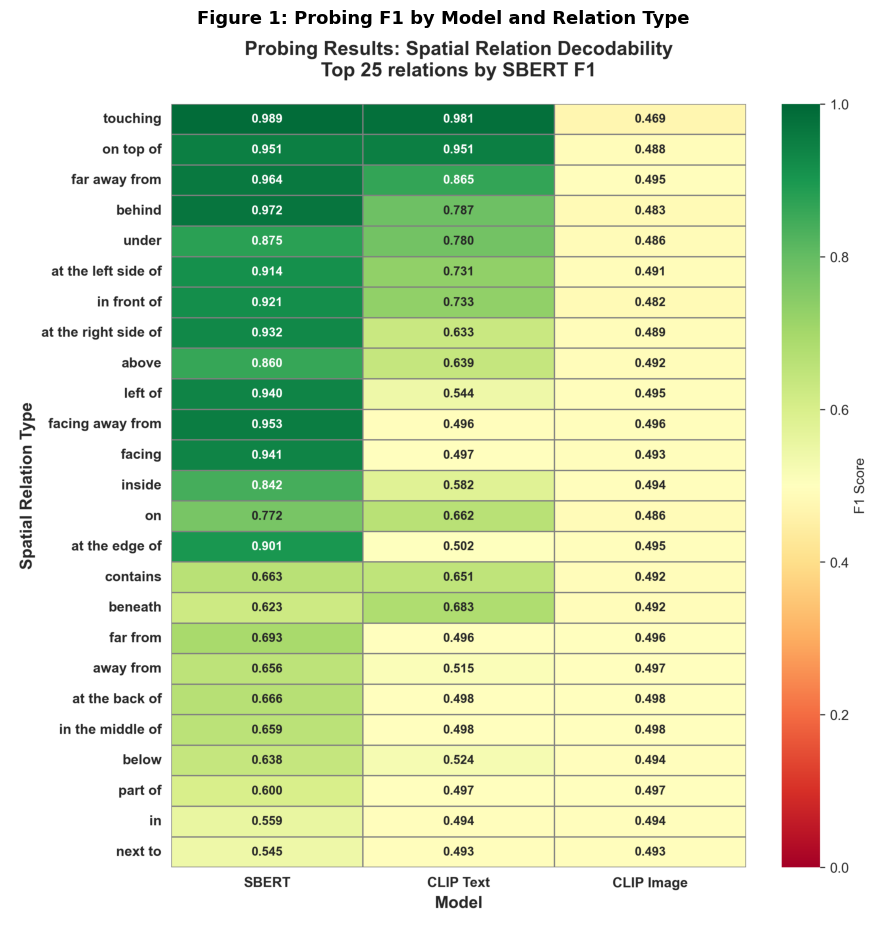

In [6]:
# F1 Heatmap showing whether relation is linearly decodable from model embeddings
img = mpimg.imread(FIGURES_DIR / "05_main_heatmap.png")
fig, ax = plt.subplots(figsize=(9, 14))
ax.imshow(img)
ax.axis("off")
ax.set_title("Figure 1: Probing F1 by Model and Relation Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 5. Discussion

See PDF submitted with this notebook.
